# Exploration

Notebook for first checks of raw data, engineered features and model predictions.

In [ ]:
from pathlib import Path
import pandas as pd

pd.set_option('display.float_format', lambda value: f'{value:.5f}')
experiment_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
raw_path = experiment_root / 'data' / 'raw' / 'tech_stocks_raw.csv'
features_path = experiment_root / 'data' / 'processed' / 'tech_stocks_features.csv'

raw_path, features_path

In [ ]:
raw_data = pd.read_csv(raw_path, parse_dates=['Date'])
raw_data.head()

In [ ]:
raw_data.groupby('Ticker')['Close'].describe()

In [ ]:
feature_data = pd.read_csv(features_path, parse_dates=['Date'])
feature_data[['Date', 'Ticker', 'Close', 'Daily_Return', 'RSI_14', 'MACD', 'Target']].head()

## Presentation Diagrams

Additional plots for the project presentation.

In [1]:

# Rohdaten - nicht unsere Daten
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Wir schalten das Gitter komplett ab für einen absolut reinen, weißen Hintergrund
sns.set_theme(style="white")

# 2. Erstellen der Figur mit rein weißem Hintergrund für die gesamte Grafik
plt.figure(figsize=(14, 7), facecolor='white')

# 3. Linien plotten mit einer sehr klaren, kontrastreichen Farbpalette
# 'tab10' sorgt dafür, dass sich die 10 Aktien farblich perfekt voneinander abheben
ax = sns.lineplot(
    data=raw_data,
    x='Date',
    y='Close',
    hue='Ticker',
    palette='tab10',
    linewidth=2.0
)

# 4. Titel und Beschriftungen in einem gut lesbaren Dunkelgrau
plt.title('Historische Schlusskurse der 10 Tech-Aktien (2019 - 2026)', fontsize=16, fontweight='bold', color='#222222')
plt.xlabel('Datum', fontsize=12, color='#222222')
plt.ylabel('Schlusskurs (USD)', fontsize=12, color='#222222')

# 5. Legende perfekt auf weißem Hintergrund platzieren
plt.legend(title='Aktien-Ticker', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, facecolor='white', edgecolor='none')

# 6. Unnötige schwarze Rahmenlinien oben und rechts entfernen (wirkt noch offener und heller)
sns.despine()

plt.tight_layout()
plt.show()

NameError: name 'raw_data' is not defined

<Figure size 1400x700 with 0 Axes>

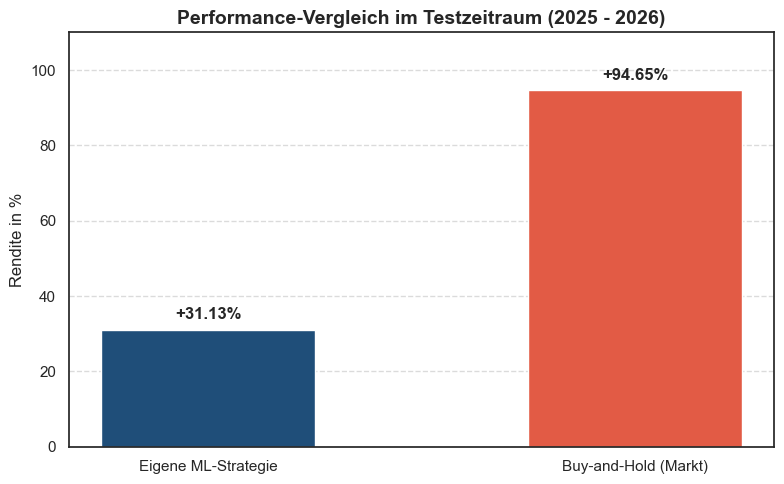

In [11]:
import matplotlib.pyplot as plt
# Gewinne nach unseren Modell vs. Tatsächlichen Gewinn
# Echte Ergebnisse aus eurem Terminal-Durchlauf eintragen
ergebnisse = {
    'Eigene ML-Strategie': 31.13,
    'Buy-and-Hold (Markt)': 94.65
}

# Diagramm erstellen
plt.figure(figsize=(8, 5))
farben = ['#1F4E79', '#E25B45'] # Blau für euch, Rot für den Markt

bars = plt.bar(ergebnisse.keys(), ergebnisse.values(), color=farben, width=0.5)

# Prozentzahlen oben auf die Balken schreiben
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f"+{yval}%", ha='center', va='bottom', fontweight='bold')

plt.title('Performance-Vergleich im Testzeitraum (2025 - 2026)', fontsize=14, fontweight='bold')
plt.ylabel('Rendite in %', fontsize=12)
plt.ylim(0, 110) # Platz nach oben lassen für die Beschriftung
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

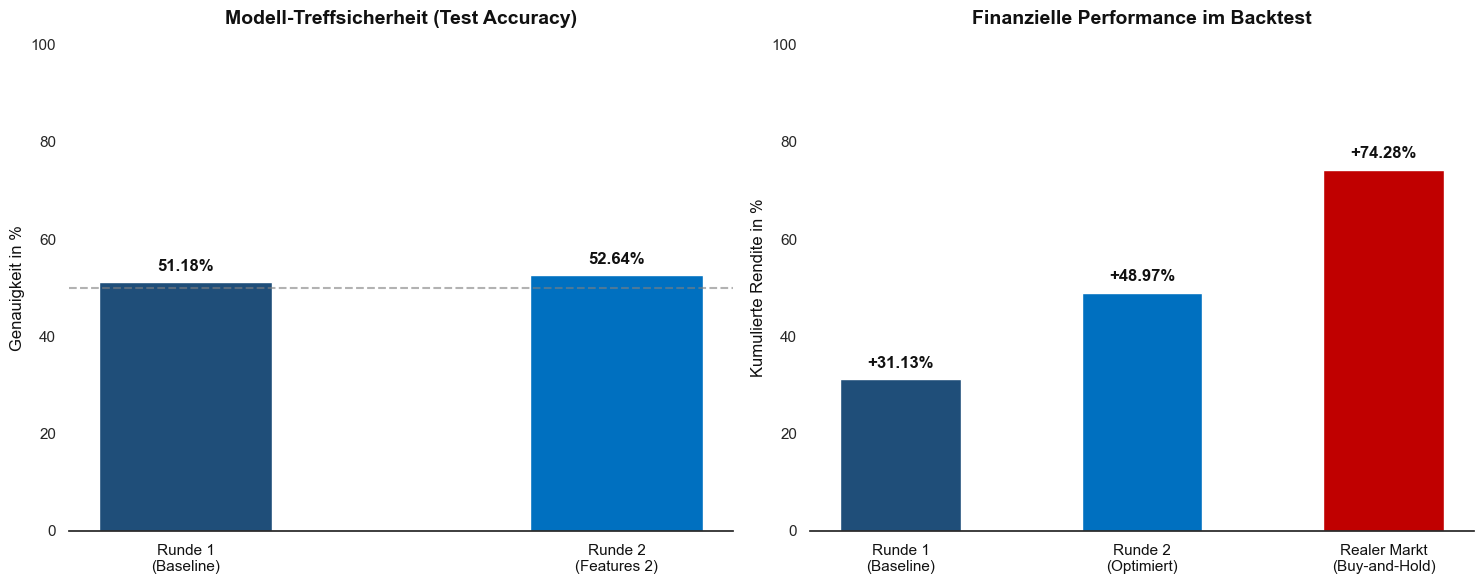

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

accuracy_runde1 = 51.18
rendite_runde1 = 31.13

accuracy_runde2 = 52.64
rendite_runde2 = 48.97

rendite_markt = 74.28

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), facecolor='white')

labels_acc = ['Runde 1\n(Baseline)', 'Runde 2\n(Features 2)']
values_acc = [accuracy_runde1, accuracy_runde2]

kraeftige_farben_acc = ['#1F4E79', '#0070C0']
bars1 = ax1.bar(labels_acc, values_acc, color=kraeftige_farben_acc, width=0.4)

ax1.set_title('Modell-Treffsicherheit (Test Accuracy)', fontsize=14, fontweight='bold', pad=15, color='#111111')
ax1.set_ylabel('Genauigkeit in %', fontsize=12, color='#111111')
ax1.set_ylim(0, 100)
ax1.axhline(50, color='gray', linestyle='--', alpha=0.6)

for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.2f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 6), textcoords="offset points", ha='center', va='bottom', fontweight='bold', fontsize=12, color='#111111')

labels_ret = ['Runde 1\n(Baseline)', 'Runde 2\n(Optimiert)', 'Realer Markt\n(Buy-and-Hold)']
values_ret = [rendite_runde1, rendite_runde2, rendite_markt]

kraeftige_farben_ret = ['#1F4E79', '#0070C0', '#C00000']
bars2 = ax2.bar(labels_ret, values_ret, color=kraeftige_farben_ret, width=0.5)

ax2.set_title('Finanzielle Performance im Backtest', fontsize=14, fontweight='bold', pad=15, color='#111111')
ax2.set_ylabel('Kumulierte Rendite in %', fontsize=12, color='#111111')
ax2.set_ylim(0, 100)

for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'+{height:.2f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 6), textcoords="offset points", ha='center', va='bottom', fontweight='bold', fontsize=12, color='#111111')

sns.despine(left=True, top=True, right=True)

ax1.tick_params(axis='x', labelsize=11, labelcolor='#111111')
ax2.tick_params(axis='x', labelsize=11, labelcolor='#111111')

plt.tight_layout()
plt.show()

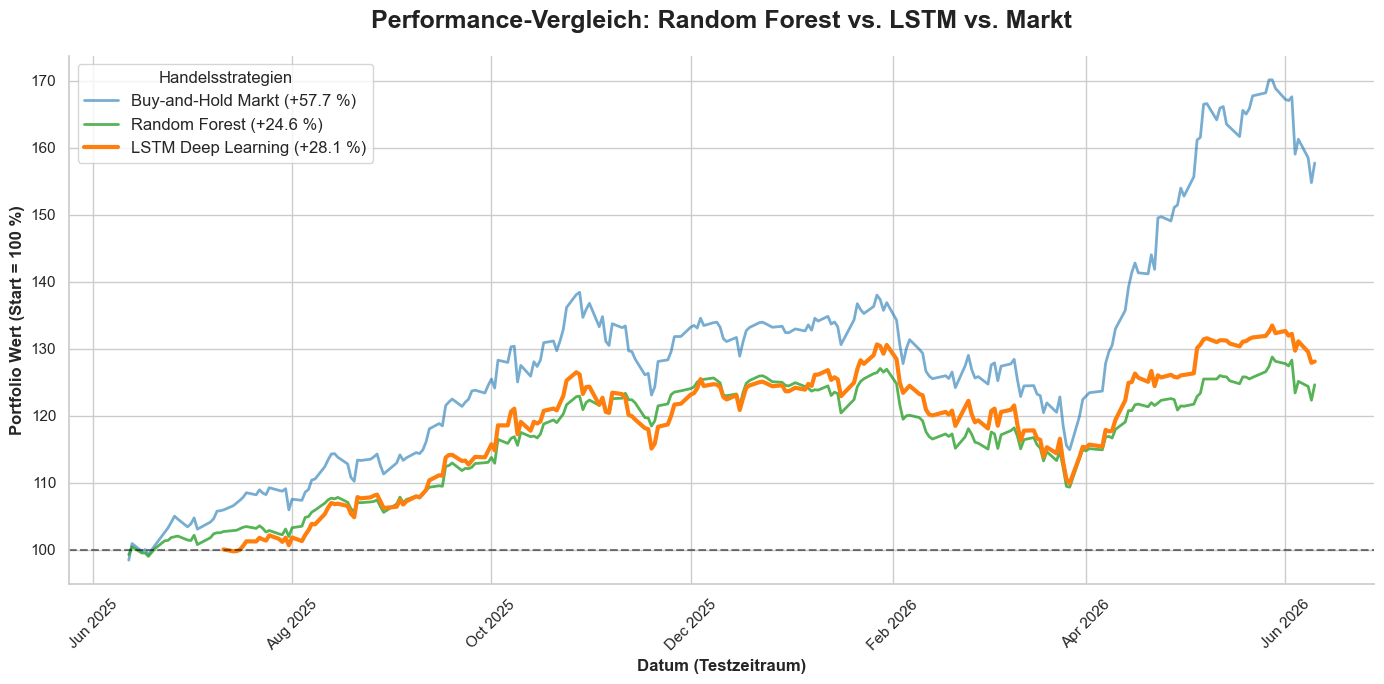

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# ==========================================
# 1. DATEN LADEN (Absolutpfade)
# ==========================================
rf_file = 'C:/Users/keith/OneDrive/Dokumente/HTW/Untersoftware/dataScienceProject/tech_stock_prediction/experiments/exp_1_1/data/processed/backtest_results.csv'
lstm_file = 'C:/Users/keith/OneDrive/Dokumente/HTW/Untersoftware/dataScienceProject/tech_stock_prediction/experiments/exp_2_lstm/data/processed/lstm_backtest_results.csv'

# CSVs laden
df_rf = pd.read_csv(rf_file, parse_dates=['Date'])
df_lstm = pd.read_csv(lstm_file, parse_dates=['Date'])

# ==========================================
# 2. KUMULIERTE RENDITE BERECHNEN
# ==========================================
# Random Forest & Benchmark
daily_rf = df_rf.groupby("Date")[["Strategy_Return", "Buy_And_Hold_Return"]].mean()
equity_rf = (1 + daily_rf).cumprod() * 100

# LSTM
daily_lstm = df_lstm.groupby("Date")[["Strategy_Return"]].mean()
equity_lstm = (1 + daily_lstm).cumprod() * 100

# ==========================================
# 3. PLOTTING - Das Ultimative Finale
# ==========================================
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')

# 1. Buy and Hold (Benchmark) in Blau
ax.plot(
    equity_rf.index,
    equity_rf['Buy_And_Hold_Return'],
    color='#1f77b4',
    linewidth=2.0,
    alpha=0.6,
    label=f'Buy-and-Hold Markt (+{(equity_rf["Buy_And_Hold_Return"].iloc[-1] - 100):.1f} %)'
)

# 2. Random Forest Strategie in Grün
ax.plot(
    equity_rf.index,
    equity_rf['Strategy_Return'],
    color='#2ca02c',
    linewidth=2.0,
    alpha=0.8,
    label=f'Random Forest (+{(equity_rf["Strategy_Return"].iloc[-1] - 100):.1f} %)'
)

# 3. LSTM Strategie in Orange (Der Gewinner)
ax.plot(
    equity_lstm.index,
    equity_lstm['Strategy_Return'],
    color='#ff7f0e',
    linewidth=3.0, # Etwas dicker für den visuellen Fokus
    label=f'LSTM Deep Learning (+{(equity_lstm["Strategy_Return"].iloc[-1] - 100):.1f} %)'
)

# Startlinie bei 100%
ax.axhline(100, color='black', linewidth=1.5, linestyle='--', alpha=0.5)

# X-Achse Formatierung
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Beschriftungen
plt.title('Performance-Vergleich: Random Forest vs. LSTM vs. Markt', fontsize=18, fontweight='bold', color='#222222', pad=20)
plt.xlabel('Datum (Testzeitraum)', fontsize=12, fontweight='bold')
plt.ylabel('Portfolio Wert (Start = 100 %)', fontsize=12, fontweight='bold')

# Legende
plt.legend(title='Handelsstrategien', loc='upper left', frameon=True, facecolor='white', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()